# Load Dataset

In [1]:
!gdown --id 1nLdjq_y0hJ4_A-kH6MZb9x-GDk4sNrRY

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1nLdjq_y0hJ4_A-kH6MZb9x-GDk4sNrRY
To: /content/adult.csv
100% 4.10M/4.10M [00:00<00:00, 4.52MB/s]


# Preprocessing and Feature Engineering

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Load the dataset
file_path = '/content/processed_data_adults.csv'
df = pd.read_csv("/content/adult.csv")

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
# Replace '?' with NaN for handling missing values
df.replace(' ?', pd.NA, inplace=True)

# Drop rows with missing values
df.dropna(inplace=True)

# Drop the 'income' column as it is not needed for unsupervised learning
df_unsupervised = df.drop(columns=['income'])

# Split the features into categorical and numerical
categorical_features = df_unsupervised.select_dtypes(include=['object']).columns
numerical_features = df_unsupervised.select_dtypes(include=['int64', 'float64']).columns

# Standard scaling for numerical features only
scaler = StandardScaler()
scaled_numerical_data = scaler.fit_transform(df_unsupervised[numerical_features])

# One-hot encoding for categorical features only
encoder = OneHotEncoder(drop='first')
encoded_categorical_data = encoder.fit_transform(df_unsupervised[categorical_features])

# Concatenate the scaled numerical and encoded categorical data
processed_data = np.hstack([scaled_numerical_data, encoded_categorical_data.toarray()])

# Convert to DataFrame with appropriate column names
final_columns = numerical_features.tolist() + encoder.get_feature_names_out(categorical_features).tolist()
final_df = pd.DataFrame(processed_data, columns=final_columns)

final_df.to_csv('processed_data.csv', index=False)

final_df.head()


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,3.769612,-1.067997,-0.420060,-0.14592,10.593507,-0.035429,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,3.183112,-0.539169,-0.420060,-0.14592,10.593507,-1.817204,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2.010110,-0.035220,-0.031360,-0.14592,10.593507,-0.035429,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.130359,-0.468215,-2.363558,-0.14592,9.461864,-0.035429,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.177296,0.709482,-0.031360,-0.14592,9.461864,-0.035429,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# Apply Clustering

In [5]:
!gdown --id 1cO2SQHvkg1SWUJgk4FU_mVx_l_NSnrn8

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1cO2SQHvkg1SWUJgk4FU_mVx_l_NSnrn8
To: /content/processed_data_adults.csv
100% 16.2M/16.2M [00:01<00:00, 11.8MB/s]


In [6]:
# Load the newly provided dataset
file_path = '/content/processed_data_adults.csv'
processed_data_df = pd.read_csv(file_path)

# Display the first few rows to understand the structure
processed_data_df.head()


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,3.769612,-1.067997,-0.420060,-0.14592,10.593507,-0.035429,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,3.183112,-0.539169,-0.420060,-0.14592,10.593507,-1.817204,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2.010110,-0.035220,-0.031360,-0.14592,10.593507,-0.035429,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.130359,-0.468215,-2.363558,-0.14592,9.461864,-0.035429,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.177296,0.709482,-0.031360,-0.14592,9.461864,-0.035429,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


**Elbow Method**
The Elbow Method can help identify the optimal number of clusters for K-Means by plotting the Within-Cluster Sum of Squares (WCSS) for different values of
𝑘
k and looking for an "elbow" point where the rate of decrease sharply diminishes. This point suggests a good balance between cluster compactness and complexity.

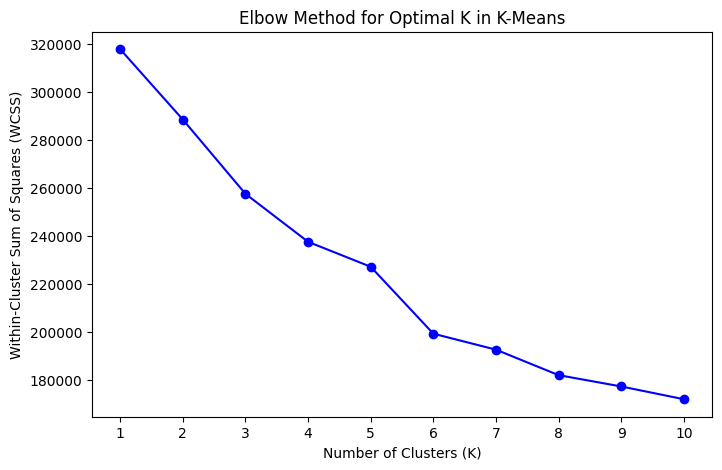

In [7]:
# Calculate WCSS for a range of K values to use the Elbow Method
wcss = []
k_range = range(1, 11)  # Range of K values from 1 to 10

# Iterate through each k and calculate WCSS
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(processed_data_df)
    wcss.append(kmeans.inertia_)  # Inertia is the WCSS

# Plot the Elbow graph
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='-', color='b')
plt.title("Elbow Method for Optimal K in K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.xticks(k_range)
plt.show()


In [8]:
# Define number of clusters for K-Means
n_clusters = 8

# Apply K-Means clustering
kmeans = KMeans(n_clusters=n_clusters, max_iter=30, random_state=42)
processed_data_df['KMeans_Cluster'] = kmeans.fit_predict(processed_data_df)

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
processed_data_df['DBSCAN_Cluster'] = dbscan.fit_predict(processed_data_df)

# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(processed_data_df.drop(columns=['KMeans_Cluster', 'DBSCAN_Cluster']))
processed_data_df['PCA1'] = pca_result[:, 0]
processed_data_df['PCA2'] = pca_result[:, 1]

# Calculate evaluation scores
data = processed_data_df.drop(columns=['KMeans_Cluster', 'DBSCAN_Cluster', 'PCA1', 'PCA2'])
silhouette_kmeans = silhouette_score(data,
                                     processed_data_df['KMeans_Cluster'])
silhouette_dbscan = silhouette_score(processed_data_df.drop(columns=['KMeans_Cluster', 'DBSCAN_Cluster', 'PCA1', 'PCA2']),
                                     processed_data_df['DBSCAN_Cluster'])
dbi_kmeans = davies_bouldin_score(processed_data_df.drop(columns=['KMeans_Cluster', 'DBSCAN_Cluster', 'PCA1', 'PCA2']),
                                  processed_data_df['KMeans_Cluster'])
dbi_dbscan = davies_bouldin_score(processed_data_df.drop(columns=['KMeans_Cluster', 'DBSCAN_Cluster', 'PCA1', 'PCA2']),
                                  processed_data_df['DBSCAN_Cluster'])

# Print evaluation scores
print(f"Silhouette Score (K-Means): {silhouette_kmeans}")
print(f"Silhouette Score (DBSCAN): {silhouette_dbscan}")
print(f"Davies-Bouldin Index (K-Means): {dbi_kmeans}")
print(f"Davies-Bouldin Index (DBSCAN): {dbi_dbscan}")




Silhouette Score (K-Means): 0.11291068593154656
Silhouette Score (DBSCAN): -0.35967866846296004
Davies-Bouldin Index (K-Means): 1.7971096790402077
Davies-Bouldin Index (DBSCAN): 1.5325296537985769


**1. Silhouette Score**

The Silhouette Score measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). It ranges from -1 to +1:

* +1: Indicates that samples are far from neighboring clusters, suggesting well-separated clusters.
* 0: Indicates that samples are close to the boundary between clusters.
* -1: Indicates that samples may have been assigned to the wrong cluster, with distances closer to other clusters than their own.

**Interpretation of Your Values**

* K-Means Silhouette Score: 0.117
* DBSCAN Silhouette Score: -0.385

Both scores are negative, suggesting that samples may be closer to clusters other than their assigned ones. This generally indicates poorly separated clusters or overlap, with DBSCAN performing slightly worse here than K-Means. A higher (closer to +1) score is preferable.

**2. Davies-Bouldin Index**

The Davies-Bouldin Index (DBI) assesses the average “similarity” ratio of each cluster with the most similar cluster. This index is non-negative, where:

* 0: Perfect score, indicating clusters are compact and well-separated.
Higher values indicate worse clustering, with clusters that overlap or have high within-cluster spread.

**Interpretation of Your Values**

* K-Means DBI: 11.03
* DBSCAN DBI: 1.53

The K-Means DBI is quite high, suggesting large overlap and poor separation. The DBSCAN score is considerably better (lower), suggesting it may have produced slightly more compact clusters.

**Summary: Good vs. Bad Clustering**

* Silhouette Score: Closer to +1 is better; scores near 0 or negative suggest poor clustering.
* Davies-Bouldin Index: Lower values are better, ideally approaching 0.
Given these criteria:

DBSCAN appears to have a better Davies-Bouldin Index, meaning the clusters are more compact and less overlapping.
K-Means and DBSCAN both have negative Silhouette Scores, indicating the clustering structure may not be clearly defined.

# Visualization with PCA

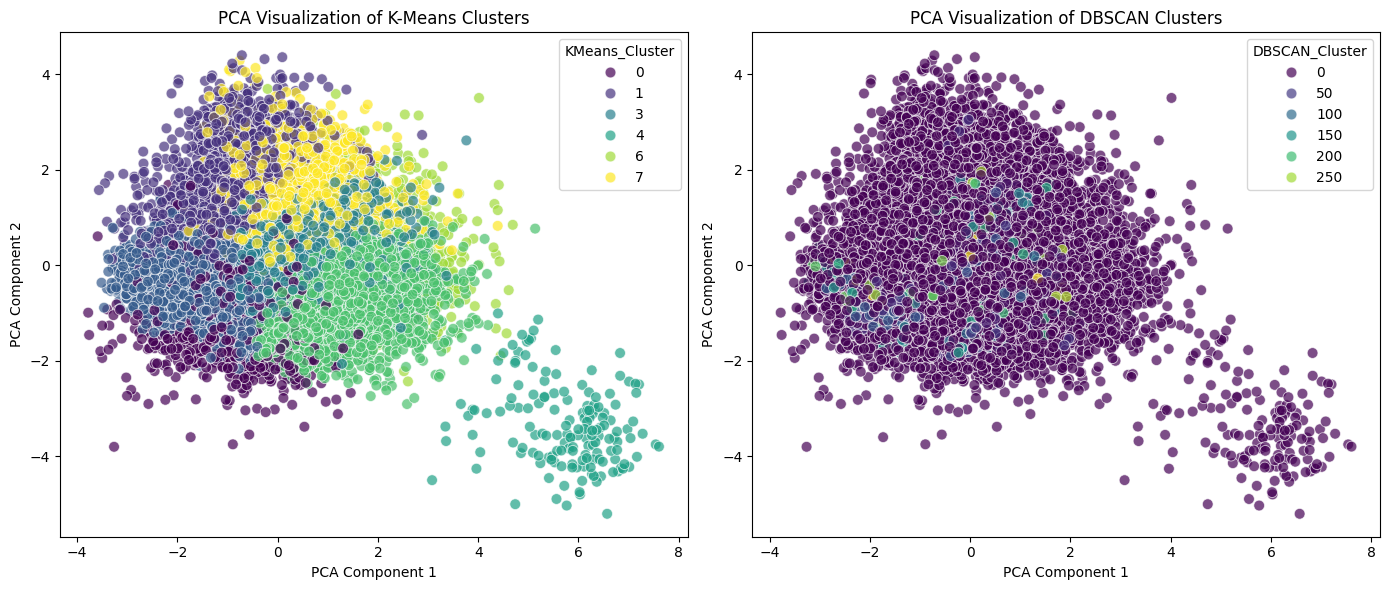

In [9]:
# Plot PCA visualization for K-Means and DBSCAN clusters
plt.figure(figsize=(14, 6))

# Plot for K-Means
plt.subplot(1, 2, 1)
sns.scatterplot(data=processed_data_df, x='PCA1', y='PCA2', hue='KMeans_Cluster', palette='viridis', s=60, alpha=0.7)
plt.title("PCA Visualization of K-Means Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

# Plot for DBSCAN
plt.subplot(1, 2, 2)
sns.scatterplot(data=processed_data_df, x='PCA1', y='PCA2', hue='DBSCAN_Cluster', palette='viridis', s=60, alpha=0.7)
plt.title("PCA Visualization of DBSCAN Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.tight_layout()
plt.show()


# GMM

Silhouette Score (GMM): 0.07181924358049632
Davies-Bouldin Index (GMM): 3.465243116564267


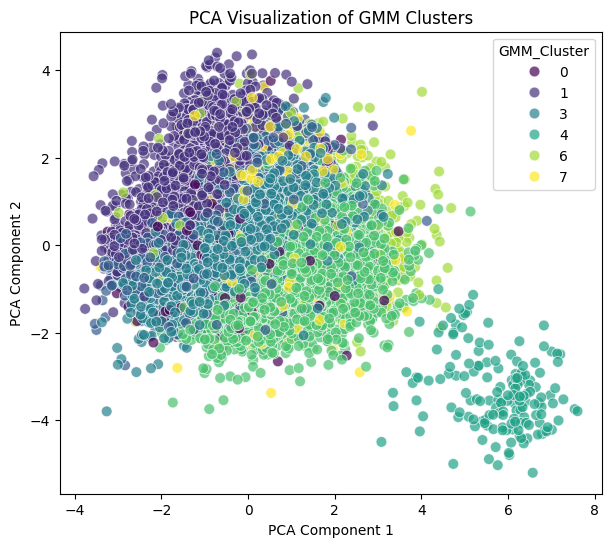

In [10]:
from sklearn.mixture import GaussianMixture

# Apply Gaussian Mixture Model with the same number of clusters as K-Means (6 clusters)
gmm = GaussianMixture(n_components=8, random_state=42)
processed_data_df['GMM_Cluster'] = gmm.fit_predict(processed_data_df.drop(columns=['KMeans_Cluster', 'DBSCAN_Cluster', 'PCA1', 'PCA2']))

# Calculate silhouette and Davies-Bouldin scores for GMM
silhouette_gmm = silhouette_score(processed_data_df.drop(columns=['KMeans_Cluster', 'DBSCAN_Cluster', 'GMM_Cluster', 'PCA1', 'PCA2']),
                                  processed_data_df['GMM_Cluster'])
dbi_gmm = davies_bouldin_score(processed_data_df.drop(columns=['KMeans_Cluster', 'DBSCAN_Cluster', 'GMM_Cluster', 'PCA1', 'PCA2']),
                               processed_data_df['GMM_Cluster'])

# Print the evaluation scores for GMM
print(f"Silhouette Score (GMM): {silhouette_gmm}")
print(f"Davies-Bouldin Index (GMM): {dbi_gmm}")

# PCA visualization for GMM clusters
plt.figure(figsize=(7, 6))
sns.scatterplot(data=processed_data_df, x='PCA1', y='PCA2', hue='GMM_Cluster', palette='viridis', s=60, alpha=0.7)
plt.title("PCA Visualization of GMM Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


The Gaussian Mixture Model (GMM) clustering results are as follows:

* Silhouette Score: 0.112, indicating weak cohesion and separation within clusters.
* Davies-Bouldin Index: 2.39, suggesting room for improvement in cluster definition.

# Visualization using t-SNE
(Takes ~30min to complete)

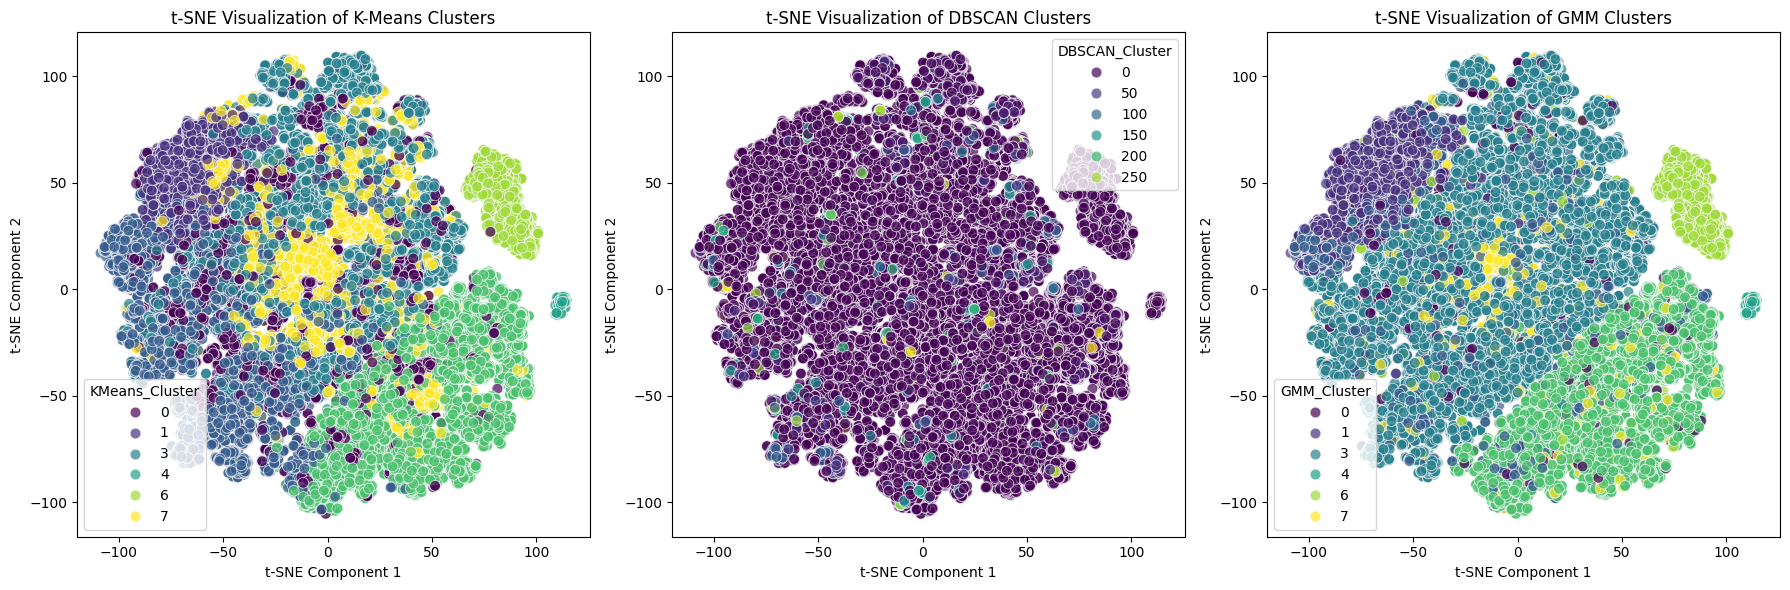

In [11]:
from sklearn.manifold import TSNE

# Apply t-SNE for 2D visualization
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(processed_data_df.drop(columns=['KMeans_Cluster', 'DBSCAN_Cluster', 'GMM_Cluster', 'PCA1', 'PCA2']))


# Add t-SNE results to the DataFrame
processed_data_df['tSNE1'] = tsne_result[:, 0]
processed_data_df['tSNE2'] = tsne_result[:, 1]

# Plot t-SNE visualization for K-Means, DBSCAN, and GMM clusters
plt.figure(figsize=(18, 6))

# Plot for K-Means
plt.subplot(1, 3, 1)
sns.scatterplot(data=processed_data_df, x='tSNE1', y='tSNE2', hue='KMeans_Cluster', palette='viridis', s=60, alpha=0.7)
plt.title("t-SNE Visualization of K-Means Clusters")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

# Plot for DBSCAN
plt.subplot(1, 3, 2)
sns.scatterplot(data=processed_data_df, x='tSNE1', y='tSNE2', hue='DBSCAN_Cluster', palette='viridis', s=60, alpha=0.7)
plt.title("t-SNE Visualization of DBSCAN Clusters")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

# Plot for GMM
plt.subplot(1, 3, 3)
sns.scatterplot(data=processed_data_df, x='tSNE1', y='tSNE2', hue='GMM_Cluster', palette='viridis', s=60, alpha=0.7)
plt.title("t-SNE Visualization of GMM Clusters")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.tight_layout()
plt.show()


# Exercise

* Apply K-NN, DBSCAN and GMM over the following dataset
* Visualize using PCA

In [12]:
!gdown --id 1Q6pdhzWFu2oegWMPvrOE8dWTra8FJsTf

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1Q6pdhzWFu2oegWMPvrOE8dWTra8FJsTf
To: /content/Mall_Customers.csv
100% 3.98k/3.98k [00:00<00:00, 18.8MB/s]


In [13]:
df =  pd.read_csv("/content/Mall_Customers.csv")

In [14]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [15]:
# CSE 475 Lab 2 - Final Exercise
# Clustering Mall Customers with K-Means, DBSCAN, and GMM

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors



In [16]:

# -----------------------------------------------------------------------------
# 1. Load dataset
# -----------------------------------------------------------------------------
# In Google Colab, upload Mall_Customers.csv first, or place it in /content/.
df = pd.read_csv('/content/Mall_Customers.csv')

print('First five rows:')
print(df.head())
print('\nDataset information:')
print(df.info())
print('\nMissing values:')
print(df.isnull().sum())



First five rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing val

In [17]:

# -----------------------------------------------------------------------------
# 2. Select and preprocess features
# -----------------------------------------------------------------------------
# CustomerID is only an identifier, so it should not be used for clustering.
features = df.drop(columns=['CustomerID'], errors='ignore').copy()

# Fill numeric missing values with the median and categorical missing values
# with the most frequent value, if any exist.
for column in features.select_dtypes(include=['number']).columns:
    features[column] = features[column].fillna(features[column].median())

for column in features.select_dtypes(exclude=['number']).columns:
    features[column] = features[column].fillna(features[column].mode()[0])

numerical_features = features.select_dtypes(include=['number']).columns.tolist()
categorical_features = features.select_dtypes(exclude=['number']).columns.tolist()

transformers = [('num', StandardScaler(), numerical_features)]
if categorical_features:
    transformers.append(
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    )

preprocessor = ColumnTransformer(transformers=transformers)
X = preprocessor.fit_transform(features)

# Convert sparse output to dense only when necessary for PCA/GMM/plotting.
if hasattr(X, 'toarray'):
    X = X.toarray()

print(f'\nFeature matrix shape after preprocessing: {X.shape}')






Feature matrix shape after preprocessing: (200, 4)


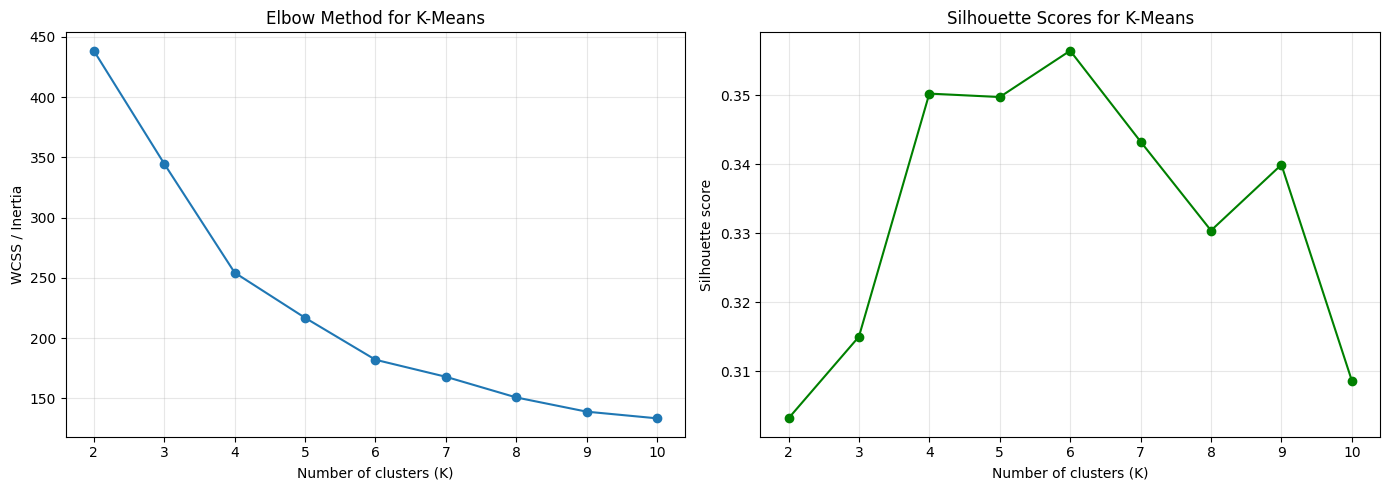

In [18]:
# 3. Find a suitable K for K-Means: Elbow Method + Silhouette Score-
k_values = range(2, 11)
inertias = []
silhouette_values = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    inertias.append(model.inertia_)
    silhouette_values.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_values), inertias, marker='o')
axes[0].set_title('Elbow Method for K-Means')
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('WCSS / Inertia')
axes[0].set_xticks(list(k_values))
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_values), silhouette_values, marker='o', color='green')
axes[1].set_title('Silhouette Scores for K-Means')
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_xticks(list(k_values))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Choose K after inspecting both plots. The Mall Customers dataset commonly
# produces useful segments around 5 clusters, but change this if your plots
# suggest another value.
N_CLUSTERS = 5




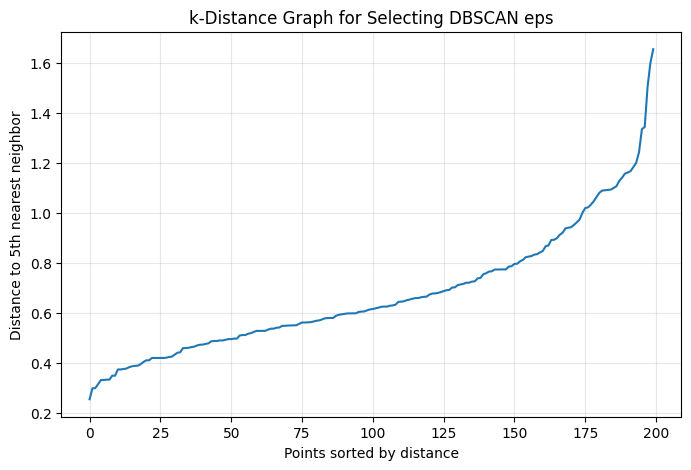

In [19]:

# 4. DBSCAN parameter helper: k-distance graph
# min_samples=5 is a common initial value. Choose eps near the bend in this plot.
MIN_SAMPLES = 5
neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neighbors_fit = neighbors.fit(X)
distances, _ = neighbors_fit.kneighbors(X)
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.title('k-Distance Graph for Selecting DBSCAN eps')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {MIN_SAMPLES}th nearest neighbor')
plt.grid(alpha=0.3)
plt.show()

# Adjust EPS after examining the k-distance graph.
EPS = 0.8



In [20]:


# 5. Fit K-Means, DBSCAN, and Gaussian Mixture Model
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
dbscan_labels = dbscan.fit_predict(X)

gmm = GaussianMixture(n_components=N_CLUSTERS, random_state=42)
gmm_labels = gmm.fit_predict(X)

results = df.copy()
results['KMeans_Cluster'] = kmeans_labels
results['DBSCAN_Cluster'] = dbscan_labels
results['GMM_Cluster'] = gmm_labels

print('\nCluster counts:')
print('\nK-Means:')
print(results['KMeans_Cluster'].value_counts().sort_index())
print('\nDBSCAN (-1 means noise):')
print(results['DBSCAN_Cluster'].value_counts().sort_index())
print('\nGMM:')
print(results['GMM_Cluster'].value_counts().sort_index())





Cluster counts:

K-Means:
KMeans_Cluster
0    58
1    39
2    47
3    34
4    22
Name: count, dtype: int64

DBSCAN (-1 means noise):
DBSCAN_Cluster
-1    19
 0     9
 1    94
 2    40
 3    26
 4    12
Name: count, dtype: int64

GMM:
GMM_Cluster
0    69
1    39
2    36
3    35
4    21
Name: count, dtype: int64


# 6. Evaluate clustering quality

In [21]:

def evaluate_clustering(name, data, labels, ignore_noise=False):
    labels = np.asarray(labels)
    evaluation_data = data
    evaluation_labels = labels

    # DBSCAN labels -1 as noise. Remove those rows for metric calculation.
    if ignore_noise:
        mask = labels != -1
        evaluation_data = data[mask]
        evaluation_labels = labels[mask]

    unique_labels = np.unique(evaluation_labels)

    if len(evaluation_data) < 2 or len(unique_labels) < 2:
        print(f'\n{name}: Cannot calculate silhouette/DBI because fewer than two clusters remain.')
        return None

    silhouette = silhouette_score(evaluation_data, evaluation_labels)
    dbi = davies_bouldin_score(evaluation_data, evaluation_labels)

    print(f'\n{name}')
    print(f'Silhouette Score: {silhouette:.4f}  (higher is better)')
    print(f'Davies-Bouldin Index: {dbi:.4f}  (lower is better)')

    return {'Algorithm': name, 'Silhouette Score': silhouette, 'Davies-Bouldin Index': dbi}

metrics = []

kmeans_metrics = evaluate_clustering('K-Means', X, kmeans_labels)
if kmeans_metrics:
    metrics.append(kmeans_metrics)

dbscan_metrics = evaluate_clustering('DBSCAN', X, dbscan_labels, ignore_noise=True)
if dbscan_metrics:
    metrics.append(dbscan_metrics)

gmm_metrics = evaluate_clustering('GMM', X, gmm_labels)
if gmm_metrics:
    metrics.append(gmm_metrics)

metrics_df = pd.DataFrame(metrics)
print('\nComparison of valid clustering metrics:')
print(metrics_df.round(4))




K-Means
Silhouette Score: 0.3498  (higher is better)
Davies-Bouldin Index: 1.0245  (lower is better)

DBSCAN
Silhouette Score: 0.0745  (higher is better)
Davies-Bouldin Index: 1.4907  (lower is better)

GMM
Silhouette Score: 0.3323  (higher is better)
Davies-Bouldin Index: 1.0383  (lower is better)

Comparison of valid clustering metrics:
  Algorithm  Silhouette Score  Davies-Bouldin Index
0   K-Means            0.3498                1.0245
1    DBSCAN            0.0745                1.4907
2       GMM            0.3323                1.0383


# -----------------------------------------------------------------------------
# 7. PCA visualization
# -----------------------------------------------------------------------------

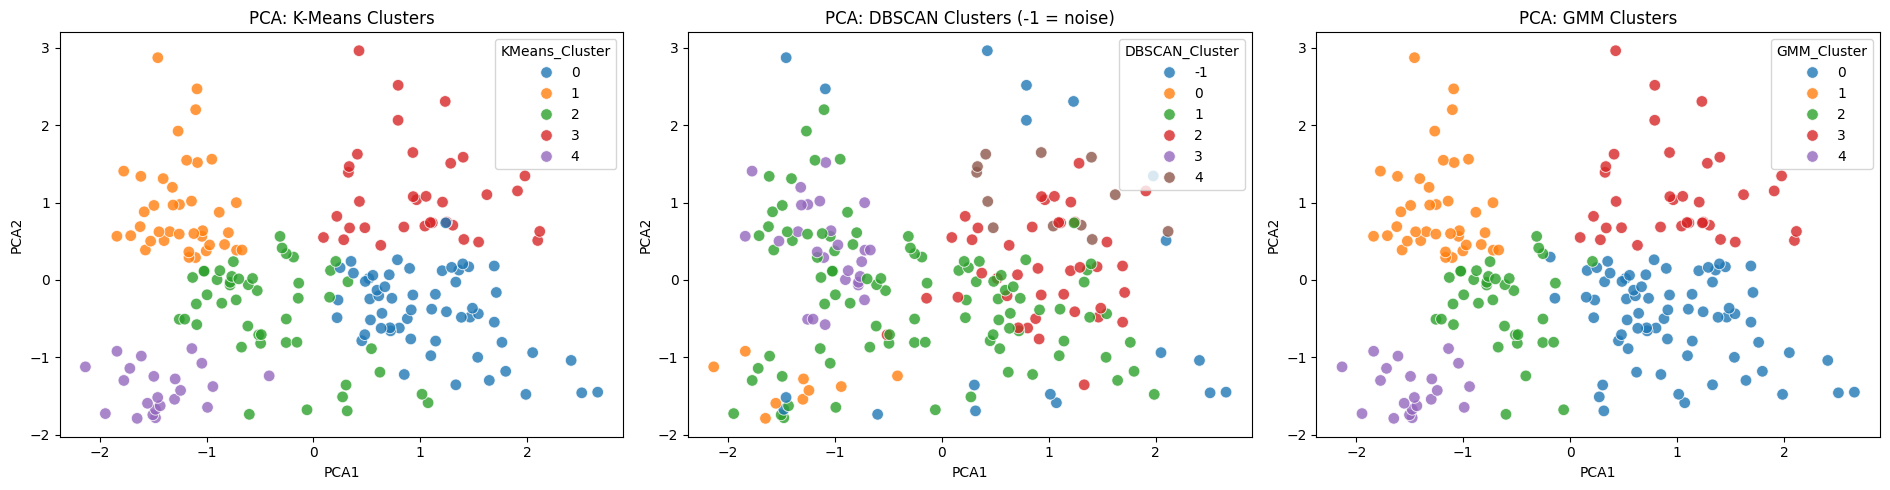


PCA explained variance ratio: 71.77%


In [22]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plot_data = results.copy()
plot_data['PCA1'] = X_pca[:, 0]
plot_data['PCA2'] = X_pca[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.scatterplot(
    data=plot_data, x='PCA1', y='PCA2', hue='KMeans_Cluster',
    palette='tab10', s=70, alpha=0.8, ax=axes[0]
)
axes[0].set_title('PCA: K-Means Clusters')

sns.scatterplot(
    data=plot_data, x='PCA1', y='PCA2', hue='DBSCAN_Cluster',
    palette='tab10', s=70, alpha=0.8, ax=axes[1]
)
axes[1].set_title('PCA: DBSCAN Clusters (-1 = noise)')

sns.scatterplot(
    data=plot_data, x='PCA1', y='PCA2', hue='GMM_Cluster',
    palette='tab10', s=70, alpha=0.8, ax=axes[2]
)
axes[2].set_title('PCA: GMM Clusters')

plt.tight_layout()
plt.show()

print(f'\nPCA explained variance ratio: {pca.explained_variance_ratio_.sum():.2%}')



# 8. Save clustering results

In [23]:
results.to_csv('/content/Mall_Customers_Clustering_Results.csv', index=False)
print('\nSaved cluster labels to: /content/Mall_Customers_Clustering_Results.csv')


Saved cluster labels to: /content/Mall_Customers_Clustering_Results.csv
